# Customer Churn Prediction
## Notebook 6 of 8 — Model Evaluation

This project predicts which telecom customers are likely to **churn** (cancel their service) so the business can reach them with retention offers *before* they leave. It walks through the full data-science lifecycle — exploration, cleaning, EDA, feature engineering, modelling, evaluation, and a tuned final model.

**Business problem:** Winning a new customer costs far more than keeping an existing one. This telecom loses roughly **27% of its customers**, and the leadership team wants a reliable, data-driven way to flag at-risk customers early enough to act.

**Tools & techniques:** Python · pandas · NumPy · Matplotlib · Seaborn · scikit-learn · XGBoost · SMOTE (imbalanced-learn) · joblib

> **This notebook:** we look beyond accuracy — using the confusion matrix and precision/recall/F1 — to expose what the baseline model actually gets wrong, and define the metric that matters for this business.

**Author:** La Yaung Linn Lett  &nbsp;·&nbsp;  **Last updated:** June 2026

---

## 1. Rebuild the baseline model

**What:** Reload the data, re-split, and refit the same Logistic Regression from Notebook 05.

**Why:** This notebook is self-contained for evaluation — we recreate the baseline so we can dissect its predictions in detail.

In [1]:
# Standard library
import warnings

# Third-party
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

warnings.filterwarnings("ignore", category=UserWarning)
FIG_DIR = "../outputs/figures"

df = pd.read_csv("../data/processed/model_ready.csv")
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Baseline model rebuilt.")

C:\Users\Vivobook\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Baseline model rebuilt.


## 2. Confusion matrix

**What:** Visualise correct vs. incorrect predictions for each class.

**Why:** The confusion matrix shows *how* the model is wrong. For churn, the most costly mistake is a **false negative** — a customer who churns but we predicted would stay, so we never tried to save them.

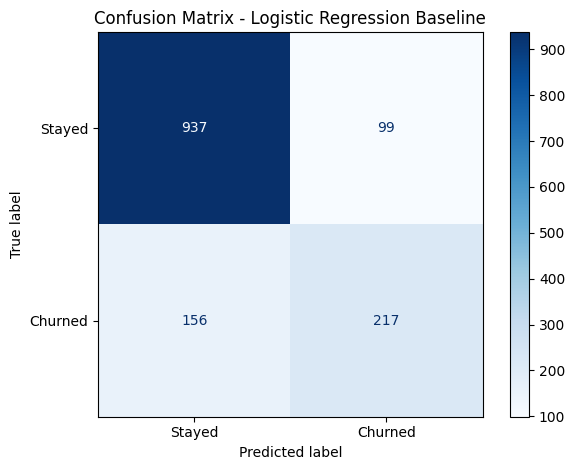

In [2]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrix_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** The bottom-left cell (churners we *missed*) is large — the baseline lets a lot of real churners slip through while correctly identifying most of the customers who stay. Those missed churners are exactly the people the business wanted to catch.

## 3. Precision, recall, and F1

**What:** Print the full classification report.

**Why:** These metrics separate the two error types. **Recall on the churn class** — what fraction of real churners we caught — is the number this project optimises for.

In [3]:
print(classification_report(y_test, y_pred,
                            target_names=["Stayed", "Churned"]))

              precision    recall  f1-score   support

      Stayed       0.86      0.90      0.88      1036
     Churned       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.81      1409



**Insight:** Despite **~82% accuracy**, the model only achieves **~0.58 recall on churners** — it misses roughly **4 in 10** customers who actually leave. This is the gap that matters: accuracy hides a model that is good at spotting stayers but mediocre at spotting churners.

## Why recall is our north-star metric

In churn prediction the costs are asymmetric:

- **False negative** (predict *stay*, customer *churns*): we lose the customer and all their future revenue — **expensive**.
- **False positive** (predict *churn*, customer *stays*): we offer an unnecessary discount — **cheap** by comparison.

So we deliberately favour **recall** (catching churners) even if it costs some precision. The business goal is to catch **at least 70% of churners**.

## Section conclusion — the baseline's real weakness

- The baseline reaches **~82% accuracy** but only **~0.58 recall** on churners.
- The confusion matrix shows **too many missed churners** (false negatives).
- For this business, **recall is the metric that matters**, with a target of catching ≥70% of churners.
- The baseline falls short of that target — so there is clear room to improve.

**Next:** Notebook 07 tackles the imbalance with stronger models, SMOTE, and threshold tuning to push recall up.